In [1]:
import pandas as pd
import sqlite3 as sql
import matplotlib.pyplot as plt

In [2]:
conn = sql.connect(r'C:\Users\gerar\OneDrive\Gerardo\9. Proyectos\App finanzas personales\Github version\Finanzas-personales\recursos\bbdd_general.db')
query = 'SELECT * FROM transacciones'

df = pd.read_sql_query(query,conn)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             7 non-null      int64 
 1   t_transaccion  7 non-null      object
 2   monto          7 non-null      object
 3   cuenta_prin    7 non-null      object
 4   cuenta_det     7 non-null      object
 5   categoria      7 non-null      object
 6   nota           7 non-null      object
 7   fecha          7 non-null      object
dtypes: int64(1), object(7)
memory usage: 580.0+ bytes


In [6]:
df['monto'] = df['monto'].astype(float)
df['fecha'] = pd.to_datetime(df['fecha'], format='%d-%m-%Y')

In [7]:
df

,id,t_transaccion,monto,cuenta_prin,cuenta_det,categoria,nota,fecha
0,1,Ingreso,1500.0,Cuenta Sueldo,Cuenta Sueldo,Comida y bebida,,2025-04-02
1,2,Gasto,500.0,Cuenta Sueldo,Cuenta Sueldo,Comida y bebida,,2025-04-02
2,3,Ingreso,7000.0,Cuenta Sueldo,Cuenta Sueldo,Comida y bebida,,2025-04-02
3,4,Gasto,500.0,Cuenta Sueldo,Cuenta Sueldo,Comida y bebida,,2025-04-02
4,5,Ingreso,7000.0,Fondo de emergencia,Cuenta Sueldo,Comida y bebida,,2025-04-02
5,6,Gasto,100.0,Fondo de emergencia,Cuenta Sueldo,Comida y bebida,,2025-04-02
6,7,Ingreso,6000.0,Cuenta Sueldo,Cuenta Sueldo,Comida y bebida,,2025-04-01


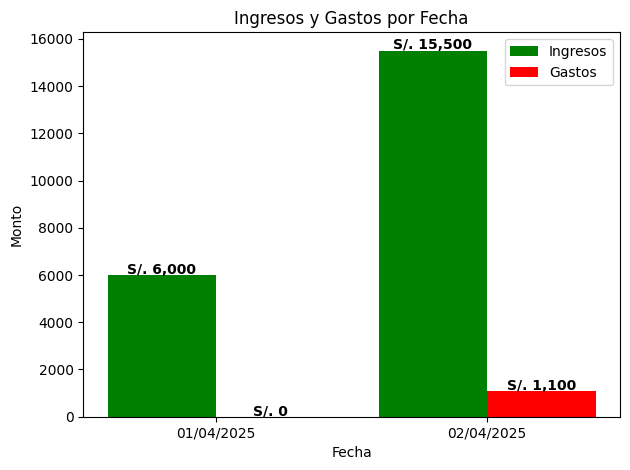

In [12]:
dias = sorted(df['fecha'].unique())

# Crear una lista de índices numéricos para el eje X
x = list(range(len(dias)))  # ✅ Ahora es una lista de índices

# Calcular ingresos y egresos por fecha
ingresos = df[df['t_transaccion'] == 'Ingreso'].groupby('fecha')['monto'].sum().reindex(dias, fill_value=0).values
egresos = df[df['t_transaccion'] == 'Gasto'].groupby('fecha')['monto'].sum().reindex(dias, fill_value=0).values

# Ancho de las barras
ancho = 0.4  

# Graficar
bars_ingresos = plt.bar([i - ancho / 2 for i in x], ingresos, ancho, label='Ingresos', color='green')
bars_egresos = plt.bar([i + ancho / 2 for i in x], egresos, ancho, label='Gastos', color='red')

for bar in bars_ingresos:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50, f'S/. {bar.get_height():,.0f}', 
             ha='center', fontsize=10, color='black', fontweight='bold')

for bar in bars_egresos:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50, f'S/. {bar.get_height():,.0f}', 
             ha='center', fontsize=10, color='black', fontweight='bold')

# Configurar el gráfico
plt.xlabel('Fecha')
plt.ylabel('Monto')
plt.title('Ingresos y Gastos por Fecha')

# Convertir fechas a string para mostrar en el eje X
plt.xticks(x, [d.strftime('%d/%m/%Y') for d in dias])  

plt.legend()
plt.tight_layout()  # Ajustar márgenes

# Mostrar el gráfico
plt.show()

In [14]:
import pyqtgraph as pg
from PyQt5.QtWidgets import QApplication, QMainWindow

class Ventana(QMainWindow):
    def __init__(self):
        super().__init__()

        # Crear un widget de gráfico
        self.grafico = pg.PlotWidget()
        self.setCentralWidget(self.grafico)

        # Datos de ejemplo
        x = [1, 2, 3, 4, 5]
        y = [10, 20, 15, 25, 30]

        # Agregar línea al gráfico
        self.grafico.plot(x, y, pen='b', symbol='o')

if __name__ == "__main__":
    app = QApplication([])
    ventana = Ventana()
    ventana.show()
    app.exec_()

ModuleNotFoundError: No module named 'pyqtgraph'